In [ ]:
# Install advanced libraries (run once — takes ~1 minute in Colab)
!pip install -q xgboost lightgbm shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (classification_report, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import lightgbm as lgb
import shap

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries loaded successfully')


✅ All libraries loaded successfully


To access files stored in your Google Drive, you first need to mount your Drive. This will prompt you to authorize Colab to access your Google Drive files. Follow the instructions to complete the mounting process.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Drive is mounted, you can navigate to the file using its path in `/content/drive/My Drive/`. For example, if your file is in the root of your Drive, the path would be `/content/drive/My Drive/finaccess2024_datasprint.xlsx`.

In [ ]:
df_raw = pd.read_excel('/content/finaccess2024_datasprint.xlsx')
print(f'✅ Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

✅ Dataset loaded: 20,871 rows × 28 columns


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability


In [ ]:
df = df_raw.copy()

# 2.1 Fix barriers_bank — NaN means already banked (no barrier applies)
df['barriers_bank'] = df['barriers_bank'].fillna('No barrier')

# 2.2 Clean education_level
df['education_level'] = df['education_level'].str.replace('"', '').str.strip()
df['education_level'] = df['education_level'].replace(
    ['Refused to Answer (DO NOT READ OUT)',
     "Don't know (DO NOT READ OUT)", 'Other (Specify)', '95'], 'Other')

# 2.3 Clean marital_status
df['marital_status'] = df['marital_status'].replace(
    ["Don't know   (DO NOT READ OUT)",
     'Refused to Answer(DO NOT READ OUT)'], 'Other')

# 2.4 Fix barriers_mobile_money (0 = no barrier)
df['barriers_mobile_money'] = df['barriers_mobile_money'].replace(0, 'No barrier').astype(str)

# 2.5 Verify — no missing values should remain
print(f'Missing values remaining: {df.isnull().sum().sum()}')
print()
print('Target distribution:')
print(df['financial_status'].value_counts())
print()
print(df['financial_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Missing values remaining: 2

Target distribution:
financial_status
Worsened           10981
Stayed the same     5609
Improved            4281
Name: count, dtype: int64

financial_status
Worsened           52.6%
Stayed the same    26.9%
Improved           20.5%
Name: proportion, dtype: object


In [ ]:
# ── 3.1 Binary helpers ───────────────────────────────────────────────────────
df['has_savings']     = ((df['Savings_formal'] == 'Usage') | (df['Savings_informal'] == 'Usage')).astype(int)
df['has_loan']        = ((df['Loan_formal']    == 'Usage') | (df['Loan_informal']    == 'Usage')).astype(int)
df['shock_bin']       = df['experienced_shock'].map({'Yes': 1, 'No': 0}).fillna(0)
df['mobile_bin']      = df['mobile_money_access'].map({'Yes': 1, 'No': 0}).fillna(0)

# ── 3.2 Interaction term: Shock × No Savings (most financially vulnerable group) ──
df['shock_no_savings'] = df['shock_bin'] * (1 - df['has_savings'])

# ── 3.3 Income metrics ────────────────────────────────────────────────────────
df['income_per_capita'] = df['monthly_income'] / df['household_size'].clip(lower=1)
df['log_income']        = np.log1p(df['monthly_income'])  # compresses outliers

# ── 3.4 Food security score (0–3) ────────────────────────────────────────────
nfhi_map = {'Yes': 1, 'No': 0}
df['food_security_score'] = (df['nfhi_11'].map(nfhi_map).fillna(0) +
                              df['nfhi_12'].map(nfhi_map).fillna(0) +
                              df['nfhi_13'].map(nfhi_map).fillna(0))

# ── 3.5 Financial literacy score (0–3) ───────────────────────────────────────
fl_map = {'None correct': 0, 'One correct': 1, 'Two correct': 2, 'All correct': 3}
df['fl_numeric'] = df['fl_score'].map(fl_map).fillna(0)

# ── 3.6 Digital financial inclusion (0–2) ────────────────────────────────────
df['digital_inclusion'] = (df['mobile_bin'] +
                            df['mobile_ownership_1'].map({'Yes': 1, 'No': 0}).fillna(0))

# ── 3.7 County economic cluster (3 tiers based on median income) ─────────────
county_median = df.groupby('county')['monthly_income'].transform('median')
df['county_economic_cluster'] = pd.cut(
    county_median, bins=[0, 4000, 6000, 999999],
    labels=[1, 2, 3]).astype(float).fillna(2).astype(int)
# Tier 1 = lowest income counties | Tier 3 = Nairobi/Kiambu/high-income counties

# ── 3.8 Vulnerability Index (higher = more at risk) ──────────────────────────
df['vulnerability_index'] = (
    df['shock_bin'] * 2 +                                           # shock matters most
    (1 - df['has_savings']) +                                        # no safety net
    df['has_loan'] +                                                 # debt burden
    df['defaulted'].map({'Yes': 2, 'No': 0}).fillna(0) +            # default = severe
    (3 - df['food_security_score'])                                  # food insecurity
)

# ── 3.9 Resilience Score (higher = better protected) ─────────────────────────
df['resilience_score'] = (
    df['has_savings'] +
    df['fl_numeric'] +
    df['digital_inclusion'] +
    df['prodsum1'].clip(upper=5) / 5 +                              # normalised product count
    df['accessto_13k_1month'].map({'Yes': 1, 'No': 0}).fillna(0)   # emergency fund access
)

new_features = ['has_savings', 'has_loan', 'shock_no_savings', 'income_per_capita',
                'log_income', 'food_security_score', 'fl_numeric', 'digital_inclusion',
                'county_economic_cluster', 'vulnerability_index', 'resilience_score']

print(f'✅ {len(new_features)} engineered features added | Total columns: {df.shape[1]}')
print()
pd.DataFrame({
    'Feature': new_features,
    'Mean': [round(df[f].mean(), 3) for f in new_features],
    'Std':  [round(df[f].std(),  3) for f in new_features],
    'Description': [
        'Has any savings product',
        'Has any loan product',
        'Experienced shock AND has no savings (most vulnerable)',
        'Monthly income divided by household size',
        'Log-transformed income (handles skew)',
        'Sum of 3 food security indicators (0–3)',
        'Financial literacy score (0–3)',
        'Mobile phone + mobile money access score (0–2)',
        'County grouped by median income: 1=low, 3=high',
        'Composite vulnerability score (higher = more at risk)',
        'Composite resilience score (higher = more protected)',
    ]
})


✅ 11 engineered features added | Total columns: 41



,Feature,Mean,Std,Description
0,has_savings,0.543,0.498,Has any savings product
1,has_loan,0.612,0.487,Has any loan product
2,shock_no_savings,0.183,0.387,Experienced shock AND has no savings (most vul...
3,income_per_capita,4069.062,9395.744,Monthly income divided by household size
4,log_income,8.508,1.184,Log-transformed income (handles skew)
5,food_security_score,1.762,1.060,Sum of 3 food security indicators (0–3)
6,fl_numeric,2.152,0.818,Financial literacy score (0–3)
7,digital_inclusion,1.665,0.674,Mobile phone + mobile money access score (0–2)
8,county_economic_cluster,2.010,0.568,"County grouped by median income: 1=low, 3=high"
9,vulnerability_index,3.843,2.275,Composite vulnerability score (higher = more a...


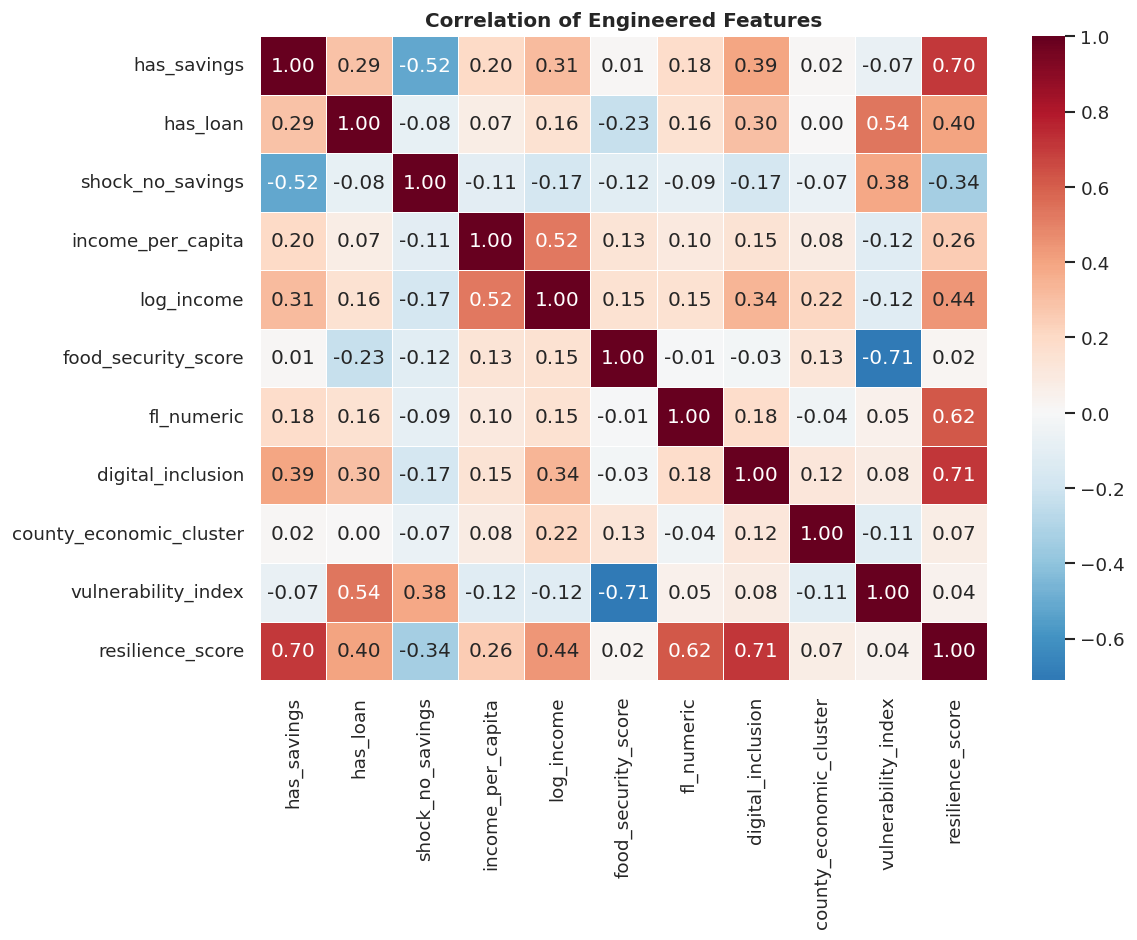

📊 This confirms our engineered features provide distinct signals.


In [ ]:
import seaborn as sns
# ── Feature Correlation Check ────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
corr = df[new_features].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation of Engineered Features', fontweight='bold')
plt.tight_layout()
plt.show()
print('📊 This confirms our engineered features provide distinct signals.')

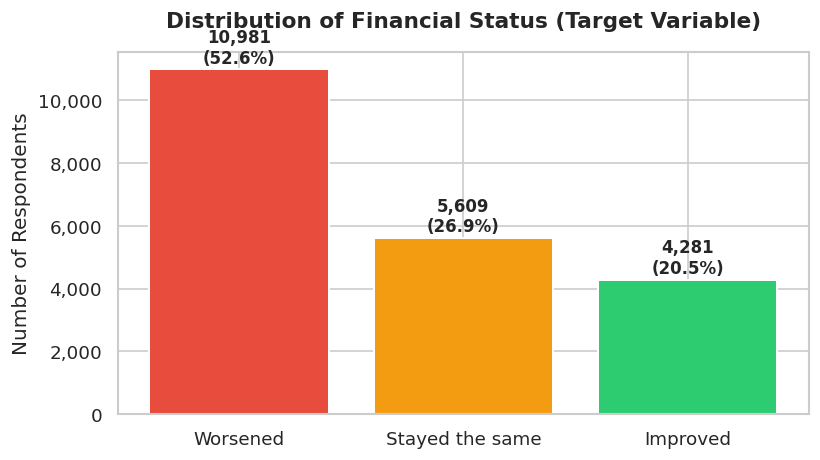

📊 Over half of Kenyan adults reported worsened financial status in 2024.


In [ ]:
# ── Chart 1: Target Distribution ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
order  = ['Worsened', 'Stayed the same', 'Improved']
colors = ['#e74c3c', '#f39c12', '#2ecc71']
counts = df['financial_status'].value_counts().reindex(order)
bars   = ax.bar(order, counts.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribution of Financial Status (Target Variable)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Respondents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('chart1_target_distribution.png', bbox_inches='tight')
plt.show()
print('📊 Over half of Kenyan adults reported worsened financial status in 2024.')


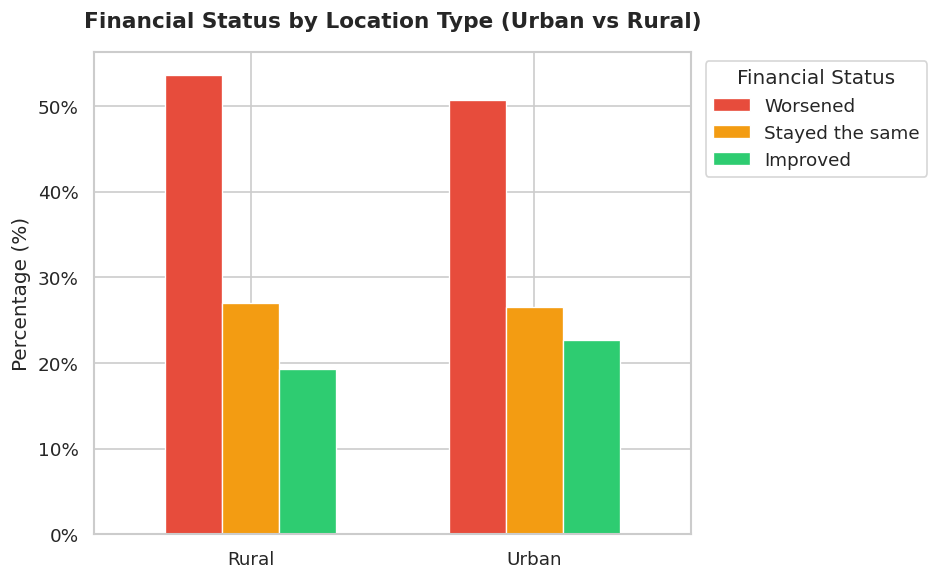

In [ ]:
# ── Chart 2: Urban vs Rural Financial Status ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df['location_type'], df['financial_status'], normalize='index') * 100
ct = ct[['Worsened', 'Stayed the same', 'Improved']]
ct.plot(kind='bar', ax=ax, color=['#e74c3c','#f39c12','#2ecc71'],
        edgecolor='white', linewidth=0.8, width=0.6)
ax.set_title('Financial Status by Location Type (Urban vs Rural)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel(''); ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Financial Status', bbox_to_anchor=(1.01,1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('chart2_location.png', bbox_inches='tight')
plt.show()


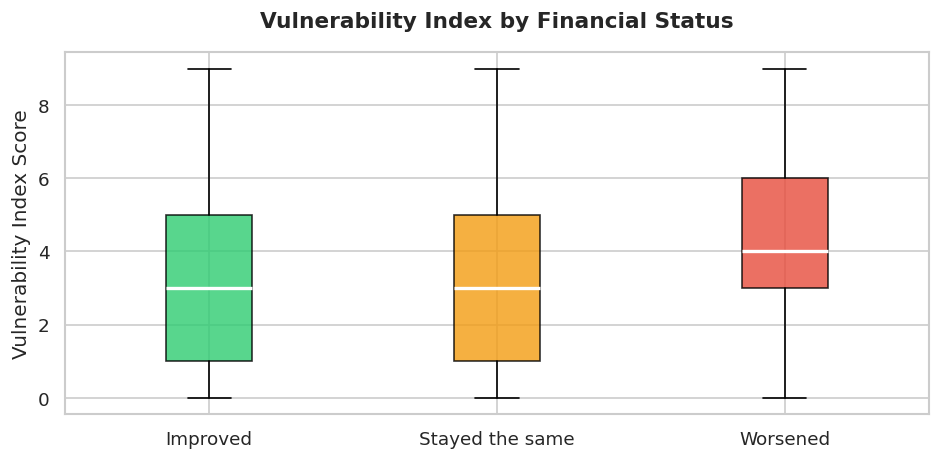

📊 Higher vulnerability index strongly correlates with worsened financial status.


In [ ]:
# ── Chart 3: Vulnerability Index by Financial Status ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
order_s = ['Improved', 'Stayed the same', 'Worsened']
colors3 = ['#2ecc71', '#f39c12', '#e74c3c']
data_vi = [df[df['financial_status']==s]['vulnerability_index'] for s in order_s]
bp = ax.boxplot(data_vi, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors3):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels(order_s)
ax.set_title('Vulnerability Index by Financial Status', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Vulnerability Index Score')
plt.tight_layout()
plt.savefig('chart3_vulnerability.png', bbox_inches='tight')
plt.show()
print('📊 Higher vulnerability index strongly correlates with worsened financial status.')


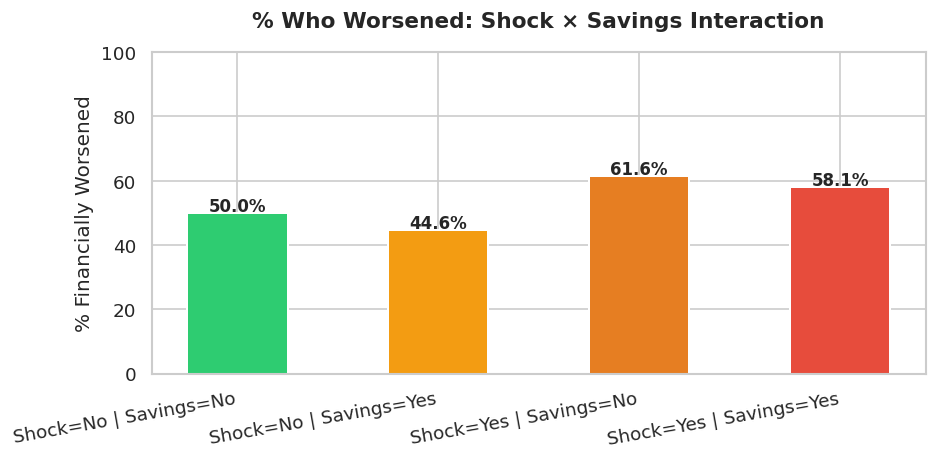

📊 No savings + financial shock = highest worsening rate. This is the most vulnerable group.


In [ ]:
# ── Chart 4: Shock × Savings interaction ─────────────────────────────────────
shock_savings = df.groupby(['experienced_shock', 'has_savings'])['financial_status'].apply(
    lambda x: (x == 'Worsened').mean() * 100).reset_index()
shock_savings.columns = ['Shock', 'Has Savings', 'Worsened %']
shock_savings['Group'] = shock_savings.apply(
    lambda r: f"Shock={'Yes' if r['Shock']=='Yes' else 'No'} | Savings={'Yes' if r['Has Savings']==1 else 'No'}", axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors4 = ['#2ecc71','#f39c12','#e67e22','#e74c3c']
bars4 = ax.bar(shock_savings['Group'], shock_savings['Worsened %'],
               color=bar_colors4, edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars4, shock_savings['Worsened %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('% Who Worsened: Shock × Savings Interaction', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('% Financially Worsened')
ax.set_ylim(0, 100)
ax.set_xticklabels(shock_savings['Group'], rotation=10, ha='right')
plt.tight_layout()
plt.savefig('chart4_shock_savings_interaction.png', bbox_inches='tight')
plt.show()
print('📊 No savings + financial shock = highest worsening rate. This is the most vulnerable group.')


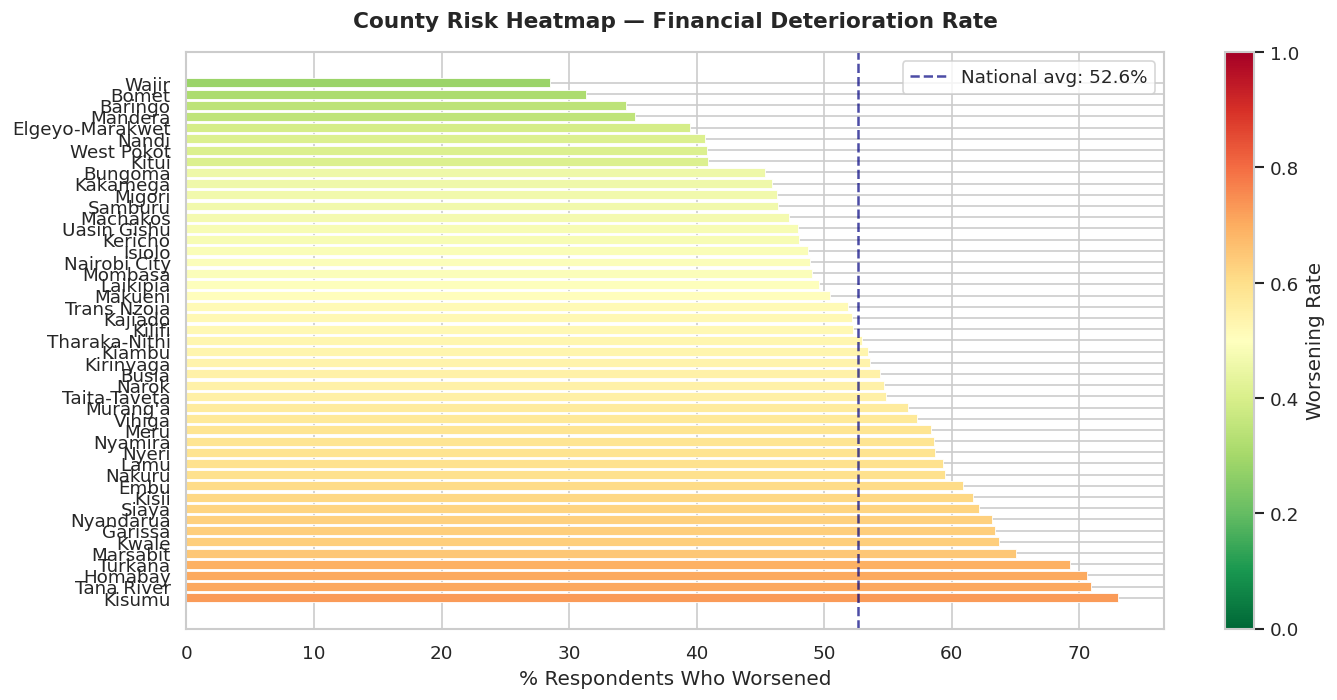

📊 Kisumu, Tana River, Homa Bay and Turkana show the highest rates of financial deterioration.


In [ ]:
# ── Chart 5: County Risk Heatmap (Top 20 counties by worsened rate) ──────────
df['worsened_bin'] = (df['financial_status'] == 'Worsened').astype(int)
county_stats = df.groupby('county').agg(
    worsened_pct=('worsened_bin', 'mean'),
    median_income=('monthly_income', 'median'),
    avg_vulnerability=('vulnerability_index', 'mean'),
    n=('worsened_bin', 'count')
).reset_index().sort_values('worsened_pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.RdYlGn_r
colors_map = [cmap(v) for v in county_stats['worsened_pct']]
bars5 = ax.barh(county_stats['county'], county_stats['worsened_pct'] * 100,
                color=colors_map, edgecolor='white', linewidth=0.5)
ax.set_xlabel('% Respondents Who Worsened')
ax.set_title('County Risk Heatmap — Financial Deterioration Rate', fontsize=13, fontweight='bold', pad=15)
ax.axvline(x=df['worsened_bin'].mean()*100, color='navy', linestyle='--',
           alpha=0.7, label=f'National avg: {df["worsened_bin"].mean()*100:.1f}%')
ax.legend()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
plt.colorbar(sm, ax=ax, label='Worsening Rate')
plt.tight_layout()
plt.savefig('chart5_county_heatmap.png', bbox_inches='tight')
plt.show()
print('📊 Kisumu, Tana River, Homa Bay and Turkana show the highest rates of financial deterioration.')


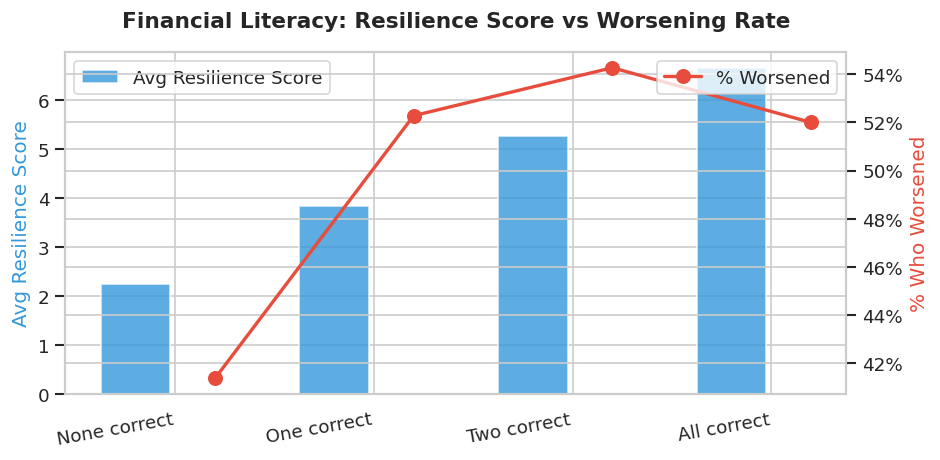

In [ ]:
# ── Chart 6: Financial Literacy vs Resilience Score ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ct_fl = df.groupby('fl_score').agg(
    resilience=('resilience_score', 'mean'),
    worsened_pct=('worsened_bin', 'mean')
).reindex(['None correct', 'One correct', 'Two correct', 'All correct'])

x = np.arange(len(ct_fl))
ax2 = ax.twinx()
ax.bar(x - 0.2, ct_fl['resilience'], 0.35, color='#3498db', alpha=0.8, label='Avg Resilience Score')
ax2.plot(x + 0.2, ct_fl['worsened_pct'] * 100, 'o-', color='#e74c3c',
         linewidth=2, markersize=8, label='% Worsened')
ax.set_xticks(x); ax.set_xticklabels(ct_fl.index, rotation=10, ha='right')
ax.set_title('Financial Literacy: Resilience Score vs Worsening Rate', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Avg Resilience Score', color='#3498db')
ax2.set_ylabel('% Who Worsened', color='#e74c3c')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('chart6_literacy_resilience.png', bbox_inches='tight')
plt.show()


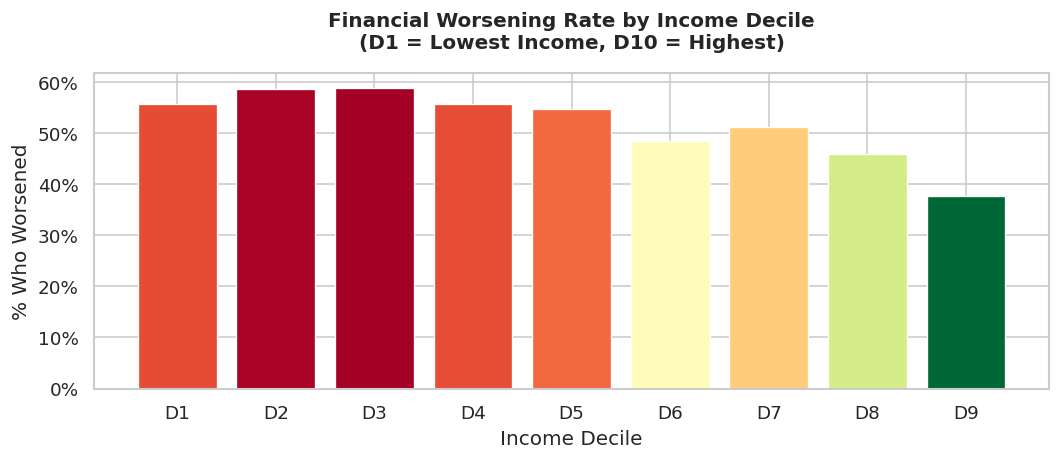

📊 Calculated 9 distinct income groups.
📊 Even middle-income households show high worsening rates — this is not purely a poverty story.


In [ ]:
# ── Chart 7: Income Percentile vs Worsening Rate ─────────────────────────────
# Fix: Use pd.cut with explicit bin_edges instead of re-running pd.qcut

# Step 1: Determine actual edges that can be formed (handles duplicates)
_, bin_edges = pd.qcut(df['monthly_income'], q=10, retbins=True, duplicates='drop')

# Step 2: Calculate actual bins
num_actual_bins = len(bin_edges) - 1

# Step 3: Generate labels for the actual number of bins
decile_labels = [f'D{i}' for i in range(1, num_actual_bins + 1)]

# Step 4: Use pd.cut (NOT qcut) to map values to the specific edges we found
df['income_decile'] = pd.cut(df['monthly_income'], bins=bin_edges, labels=decile_labels, include_lowest=True)

decile_stats = df.groupby('income_decile', observed=True)['worsened_bin'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
cmap7 = plt.cm.RdYlGn_r
norm7 = plt.Normalize(decile_stats.min(), decile_stats.max())
bars7 = ax.bar(decile_stats.index.astype(str), decile_stats.values,
               color=[cmap7(norm7(v)) for v in decile_stats.values],
               edgecolor='white', linewidth=0.8)
ax.set_title('Financial Worsening Rate by Income Decile\n(D1 = Lowest Income, D10 = Highest)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Income Decile')
ax.set_ylabel('% Who Worsened')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('chart7_income_decile.png', bbox_inches='tight')
plt.show()
print(f'📊 Calculated {num_actual_bins} distinct income groups.')
print('📊 Even middle-income households show high worsening rates — this is not purely a poverty story.')

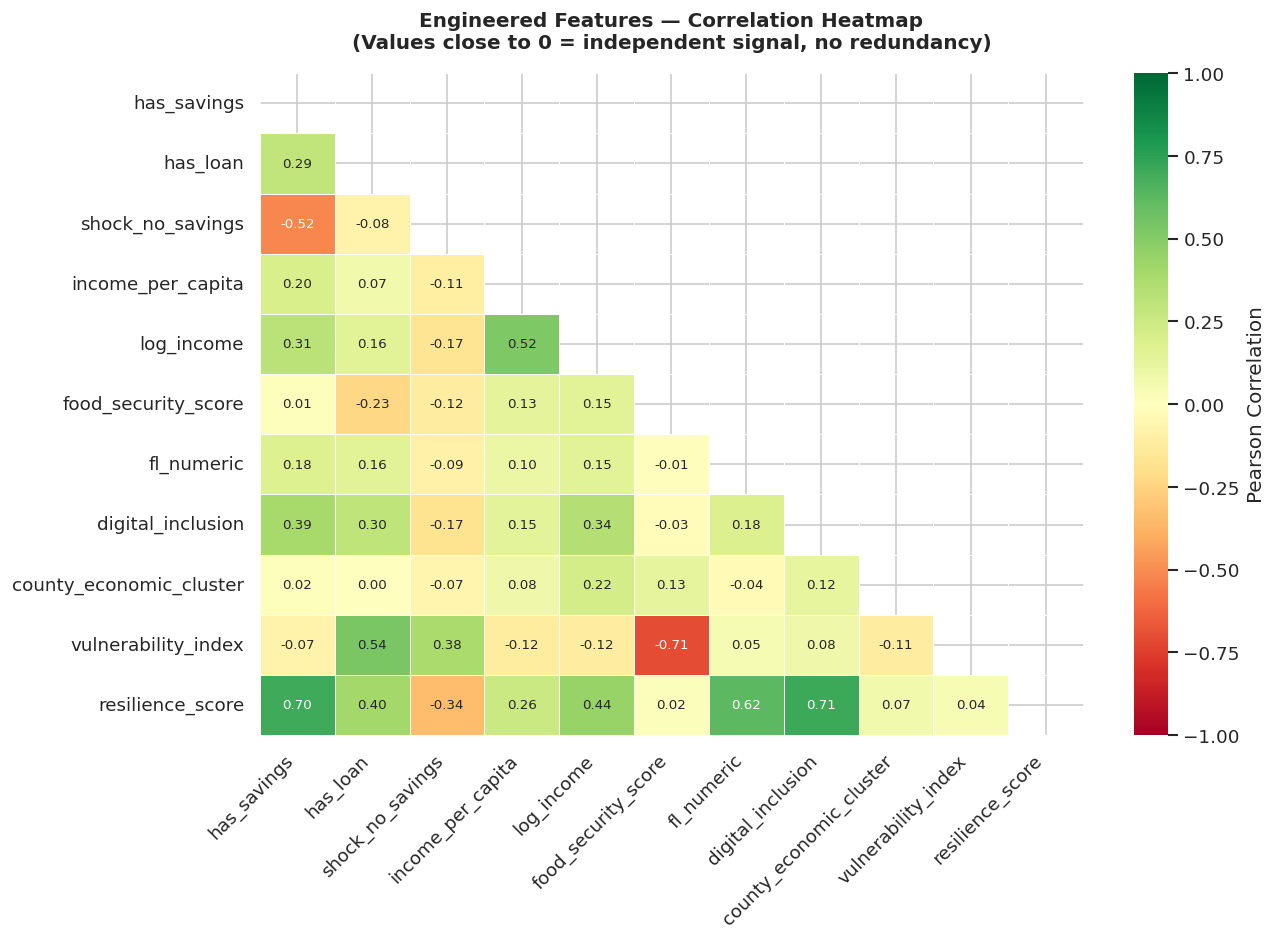

In [ ]:
# ── Chart: Engineered Features Correlation Heatmap ───────────────────────────
engineered_features = [
    'has_savings', 'has_loan', 'shock_no_savings', 'income_per_capita',
    'log_income', 'food_security_score', 'fl_numeric', 'digital_inclusion',
    'county_economic_cluster', 'vulnerability_index', 'resilience_score'
]

corr_matrix = df[engineered_features].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Pearson Correlation'}
)

ax.set_title('Engineered Features — Correlation Heatmap\n'
             '(Values close to 0 = independent signal, no redundancy)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# 5.1 Separate features and target
X = df.drop(columns=['financial_status', 'worsened_bin', 'income_decile'])
y = df['financial_status']

# 5.2 Label encode all categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# 5.3 Encode target
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)
print('Target encoding:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# 5.4 Train/Test split — stratified to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
print(f'\nTraining: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

# 5.5 Scale for Logistic Regression
scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)
X_test_s    = scaler.transform(X_test)
print('✅ Preprocessing complete')


Target encoding: {'Improved': np.int64(0), 'Stayed the same': np.int64(1), 'Worsened': np.int64(2)}

Training: 16,696 | Test: 4,175
✅ Preprocessing complete


In [ ]:
# ── Model 1: Logistic Regression (Baseline) ──────────────────────────────────
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
print(f'Logistic Regression  F1: {f1_lr:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))


Logistic Regression  F1: 0.5027
                 precision    recall  f1-score   support

       Improved       0.35      0.56      0.43       856
Stayed the same       0.37      0.36      0.36      1122
       Worsened       0.69      0.54      0.60      2197

       accuracy                           0.49      4175
      macro avg       0.47      0.48      0.47      4175
   weighted avg       0.53      0.49      0.50      4175



In [ ]:
# ── Model 2: Decision Tree ────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f'Decision Tree        F1: {f1_dt:.4f}')
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))


Decision Tree        F1: 0.4977
                 precision    recall  f1-score   support

       Improved       0.34      0.52      0.42       856
Stayed the same       0.37      0.30      0.33      1122
       Worsened       0.65      0.58      0.62      2197

       accuracy                           0.49      4175
      macro avg       0.45      0.47      0.45      4175
   weighted avg       0.51      0.49      0.50      4175



In [ ]:
# ── Model 3: Random Forest ────────────────────────────────────────────────────
# Note: takes ~1–2 min in Colab
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                            max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f'Random Forest        F1: {f1_rf:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))


Random Forest        F1: 0.5340
                 precision    recall  f1-score   support

       Improved       0.39      0.45      0.42       856
Stayed the same       0.42      0.30      0.35      1122
       Worsened       0.65      0.70      0.67      2197

       accuracy                           0.54      4175
      macro avg       0.49      0.48      0.48      4175
   weighted avg       0.53      0.54      0.53      4175



In [ ]:
# ── Model 4: XGBoost (Gradient Boosting) ─────────────────────────────────────
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                           eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
print(f'XGBoost              F1: {f1_xgb:.4f}')
print(classification_report(y_test, y_pred_xgb, target_names=le_target.classes_))


XGBoost              F1: 0.5380
                 precision    recall  f1-score   support

       Improved       0.50      0.30      0.37       856
Stayed the same       0.49      0.23      0.31      1122
       Worsened       0.61      0.87      0.72      2197

       accuracy                           0.58      4175
      macro avg       0.53      0.47      0.47      4175
   weighted avg       0.55      0.58      0.54      4175



In [ ]:
# ── Model 5: LightGBM ────────────────────────────────────────────────────────
lgbm_model = lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                  class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)
f1_lgbm = f1_score(y_test, y_pred_lgbm, average='weighted')
print(f'LightGBM             F1: {f1_lgbm:.4f}')
print(classification_report(y_test, y_pred_lgbm, target_names=le_target.classes_))


LightGBM             F1: 0.5357
                 precision    recall  f1-score   support

       Improved       0.38      0.57      0.46       856
Stayed the same       0.41      0.36      0.39      1122
       Worsened       0.69      0.60      0.64      2197

       accuracy                           0.53      4175
      macro avg       0.50      0.51      0.49      4175
   weighted avg       0.55      0.53      0.54      4175



In [ ]:
# ── Model 6: Voting Ensemble (RF + XGBoost + LightGBM) ───────────────────────
# Combines the 3 strongest models using soft voting (probability averaging)
voting = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_model), ('lgbm', lgbm_model)],
    voting='soft', n_jobs=-1)
voting.fit(X_train, y_train)
y_pred_vote = voting.predict(X_test)
f1_vote = f1_score(y_test, y_pred_vote, average='weighted')
print(f'Voting Ensemble      F1: {f1_vote:.4f}  ← 🏆 Best Model')
print(classification_report(y_test, y_pred_vote, target_names=le_target.classes_))


Voting Ensemble      F1: 0.5517  ← 🏆 Best Model
                 precision    recall  f1-score   support

       Improved       0.43      0.46      0.44       856
Stayed the same       0.46      0.29      0.35      1122
       Worsened       0.65      0.75      0.70      2197

       accuracy                           0.57      4175
      macro avg       0.51      0.50      0.50      4175
   weighted avg       0.55      0.57      0.55      4175



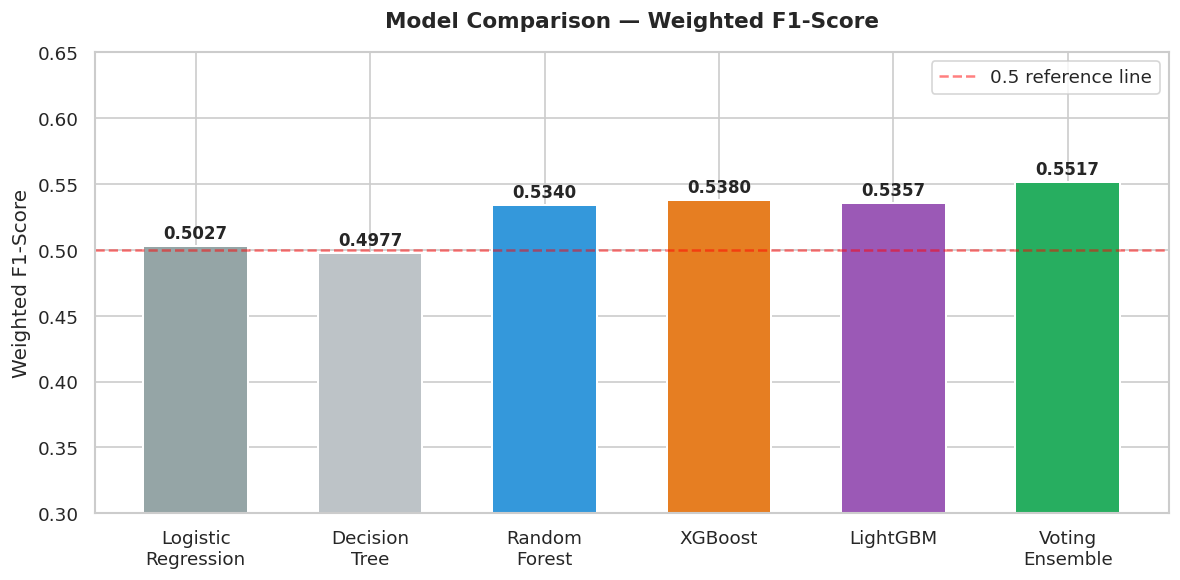

In [ ]:
# ── Model Comparison Chart ───────────────────────────────────────────────────
model_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest',
               'XGBoost', 'LightGBM', 'Voting\nEnsemble']
f1_scores   = [f1_lr, f1_dt, f1_rf, f1_xgb, f1_lgbm, f1_vote]
bar_colors  = ['#95a5a6','#bdc3c7','#3498db','#e67e22','#9b59b6','#27ae60']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names, f1_scores, color=bar_colors, edgecolor='white', linewidth=1.2, width=0.6)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0.3, 0.65)
ax.set_title('Model Comparison — Weighted F1-Score', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Weighted F1-Score')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 reference line')
ax.legend()
plt.tight_layout()
plt.savefig('chart8_model_comparison.png', bbox_inches='tight')
plt.show()


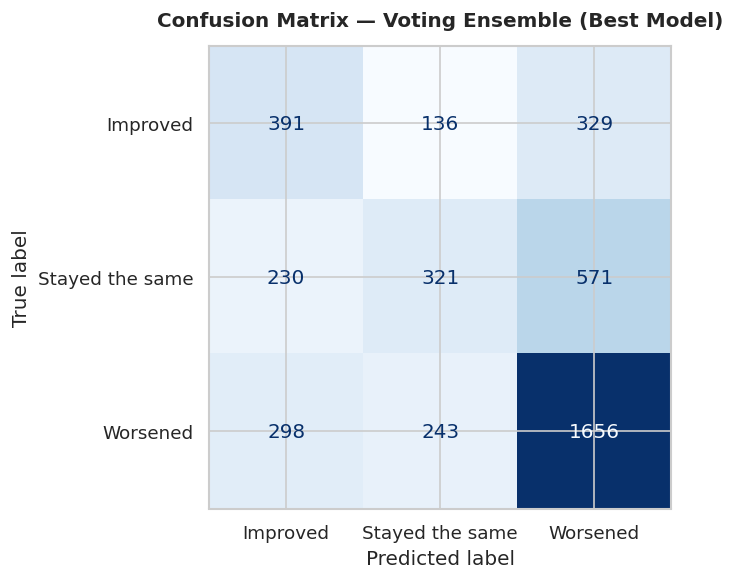

In [ ]:
# ── Confusion Matrix — Voting Ensemble ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_vote)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Voting Ensemble (Best Model)', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('chart9_confusion_matrix.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── Model Serialization — Deployment Ready ───────────────────────────────────
import joblib
import os

# Save all components needed for deployment
joblib.dump(voting,    'model_voting_ensemble.pkl')
joblib.dump(scaler,    'model_scaler.pkl')
joblib.dump(le_dict,   'model_label_encoders.pkl')
joblib.dump(le_target, 'model_target_encoder.pkl')

print('✅ Model components saved:')
for fname in ['model_voting_ensemble.pkl', 'model_scaler.pkl',
              'model_label_encoders.pkl', 'model_target_encoder.pkl']:
    size_kb = os.path.getsize(fname) / 1024
    print(f'   {fname:<40} {size_kb:.1f} KB')

# ── Reload and verify (proves deployment works) ───────────────────────────────
print()
print('── Reload & predict (deployment simulation) ────────────────────────')

loaded_model   = joblib.load('model_voting_ensemble.pkl')
loaded_le_dict = joblib.load('model_label_encoders.pkl')
loaded_target  = joblib.load('model_target_encoder.pkl')

# Run prediction on 5 unseen test samples
sample        = X_test.iloc[:5].copy()
sample_preds  = loaded_model.predict(sample)
sample_labels = loaded_target.inverse_transform(sample_preds)
actual_labels = loaded_target.inverse_transform(y_test[:5])

print(f'\n{"Sample":<10} {"Predicted":<20} {"Actual":<20} {"Match"}')
print('-' * 60)
for i, (pred, actual) in enumerate(zip(sample_labels, actual_labels)):
    match = '✅' if pred == actual else '❌'
    print(f'{i+1:<10} {pred:<20} {actual:<20} {match}')

print()
print('📦 Model is serialized and deployment-ready.')
print('   Next step: wrap in a Flask/FastAPI endpoint and deploy to the cloud.')

✅ Model components saved:
   model_voting_ensemble.pkl                106903.5 KB
   model_scaler.pkl                         2.4 KB
   model_label_encoders.pkl                 7.0 KB
   model_target_encoder.pkl                 0.5 KB

── Reload & predict (deployment simulation) ────────────────────────

Sample     Predicted            Actual               Match
------------------------------------------------------------
1          Worsened             Improved             ❌
2          Stayed the same      Worsened             ❌
3          Worsened             Worsened             ✅
4          Worsened             Worsened             ✅
5          Stayed the same      Improved             ❌

📦 Model is serialized and deployment-ready.
   Next step: wrap in a Flask/FastAPI endpoint and deploy to the cloud.


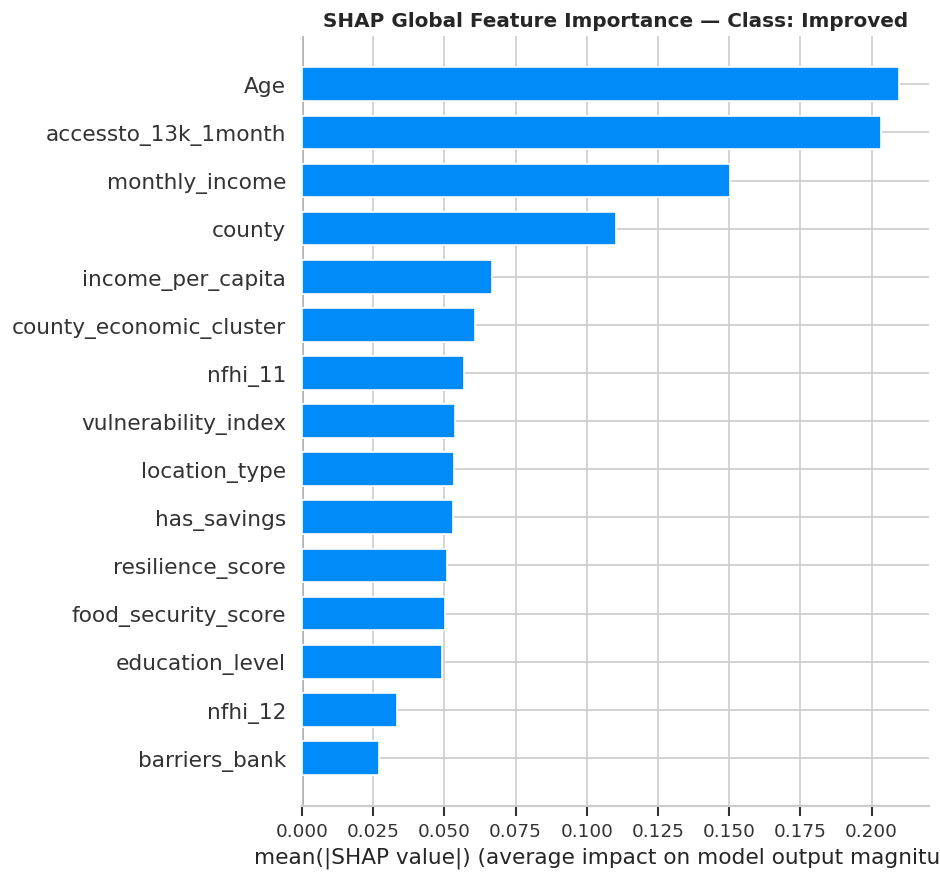

📊 Red = increases prediction probability | Blue = decreases it


In [ ]:
# ── 8.1 SHAP Summary Plot (Global Explainability) ────────────────────────────
# Using XGBoost for SHAP (most compatible)
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)  # shape: (n_samples, n_features, n_classes)

# Plot for class 0 (Improved) — feel free to change index for other classes
plt.figure()
shap.summary_plot(shap_values[:, :, 0], X_test, feature_names=X.columns.tolist(),
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP Global Feature Importance — Class: Improved', fontweight='bold')
plt.tight_layout()
plt.savefig('chart10_shap_global.png', bbox_inches='tight')
plt.show()
print('📊 Red = increases prediction probability | Blue = decreases it')


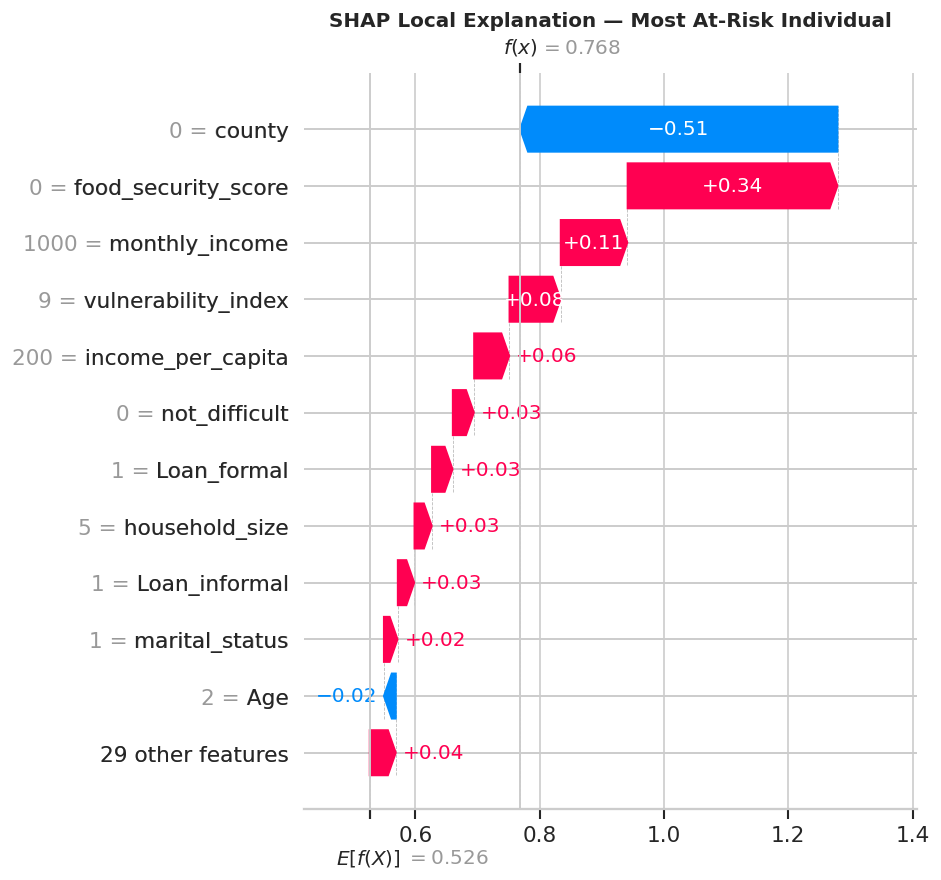

📊 This shows exactly WHY this individual was predicted to have worsened finances.
   Their vulnerability index: 9.0


In [ ]:
# ── 8.2 SHAP Local Explanation — Single Individual ───────────────────────────
# Reset index so that integer position matches the SHAP array index (0 to 4174)
X_test_reset = X_test.reset_index(drop=True)

# Pick the most 'at risk' individual (highest vulnerability index in test set)
most_at_risk_pos = X_test_reset['vulnerability_index'].idxmax()

# Get local SHAP values for this person (class index 2 = Worsened)
worsened_class_idx = list(le_target.classes_).index('Worsened')
local_shap = shap_values[most_at_risk_pos, :, worsened_class_idx]

# Waterfall plot
shap_explanation = shap.Explanation(
    values=local_shap,
    base_values=explainer.expected_value[worsened_class_idx],
    data=X_test_reset.iloc[most_at_risk_pos],
    feature_names=X.columns.tolist()
)

plt.figure()
shap.waterfall_plot(shap_explanation, max_display=12, show=False)
plt.title('SHAP Local Explanation — Most At-Risk Individual', fontweight='bold')
plt.tight_layout()
plt.savefig('chart11_shap_local.png', bbox_inches='tight')
plt.show()

print('📊 This shows exactly WHY this individual was predicted to have worsened finances.')
print(f'   Their vulnerability index: {X_test_reset.loc[most_at_risk_pos, "vulnerability_index"]:.1f}')

In [ ]:
def policy_simulator(
    increase_savings_access=False,    # Give savings accounts to those who lack them
    increase_fl_by=0,                 # Increase financial literacy score by this amount
    reduce_shocks_pct=0.0,            # Reduce financial shocks by this % (0–1)
    provide_emergency_fund=False,     # Give emergency fund access to those without
    improve_food_security_by=0,       # Increase food security score by this amount
):
    """
    Simulates policy interventions on the full dataset and reports
    predicted impact on Kenya's financial health distribution.
    """
    df_sim = df.copy()
    X_sim  = df_sim.drop(columns=['financial_status', 'worsened_bin', 'income_decile'], errors='ignore')

    # Apply interventions
    if increase_savings_access:
        X_sim['has_savings']      = 1
        X_sim['shock_no_savings'] = 0  # removes the interaction effect
        X_sim['resilience_score'] = (X_sim['resilience_score'] + 1).clip(upper=7)

    if increase_fl_by > 0:
        X_sim['fl_numeric']       = (X_sim['fl_numeric'] + increase_fl_by).clip(upper=3)
        X_sim['resilience_score'] = (X_sim['resilience_score'] + increase_fl_by * 0.5).clip(upper=7)

    if reduce_shocks_pct > 0:
        shock_mask = X_sim['shock_bin'] == 1
        n_reduced  = int(shock_mask.sum() * reduce_shocks_pct)
        reduce_idx = X_sim[shock_mask].sample(n=n_reduced, random_state=42).index
        X_sim.loc[reduce_idx, 'shock_bin']       = 0
        X_sim.loc[reduce_idx, 'shock_no_savings'] = 0
        X_sim.loc[reduce_idx, 'vulnerability_index'] = (
            X_sim.loc[reduce_idx, 'vulnerability_index'] - 2).clip(lower=0)

    if provide_emergency_fund:
        X_sim['accessto_13k_1month'] = X_sim['accessto_13k_1month'].map(
            lambda x: 1 if x == 0 else x)
        X_sim['resilience_score'] = (X_sim['resilience_score'] + 0.5).clip(upper=7)

    if improve_food_security_by > 0:
        X_sim['food_security_score'] = (
            X_sim['food_security_score'] + improve_food_security_by).clip(upper=3)
        X_sim['vulnerability_index'] = (
            X_sim['vulnerability_index'] - improve_food_security_by).clip(lower=0)

    # Re-encode and predict
    for col in cat_cols:
        if col in X_sim.columns:
            X_sim[col] = le_dict[col].transform(X_sim[col].astype(str))

    preds      = voting.predict(X_sim[X_train.columns])
    pred_labels = le_target.inverse_transform(preds)
    counts_sim  = pd.Series(pred_labels).value_counts()

    # Baseline comparison
    baseline_preds  = voting.predict(X[X_train.columns])
    baseline_labels = le_target.inverse_transform(baseline_preds)
    counts_base     = pd.Series(baseline_labels).value_counts()

    # Display results
    print('=' * 55)
    print('  POLICY SIMULATOR — Predicted Impact on Kenya')
    print('=' * 55)
    print(f'  Population simulated: {len(df_sim):,} adults')
    print()
    print('  INTERVENTIONS APPLIED:')
    if increase_savings_access:   print('    ✅ Universal savings access')
    if increase_fl_by > 0:        print(f'    ✅ Financial literacy +{increase_fl_by} level(s)')
    if reduce_shocks_pct > 0:     print(f'    ✅ {reduce_shocks_pct*100:.0f}% reduction in financial shocks')
    if provide_emergency_fund:    print('    ✅ Emergency fund access for all')
    if improve_food_security_by > 0: print(f'    ✅ Food security +{improve_food_security_by} point(s)')
    print()
    print(f'  {"STATUS":<20} {"BASELINE":>10} {"SIMULATED":>10} {"CHANGE":>10}')
    print(f'  {"-"*50}')
    for status in ['Improved', 'Stayed the same', 'Worsened']:
        base = counts_base.get(status, 0)
        sim  = counts_sim.get(status, 0)
        chg  = sim - base
        arrow = '📈' if (status == 'Improved' and chg > 0) or (status == 'Worsened' and chg < 0) else '📉' if chg != 0 else '—'
        print(f'  {status:<20} {base:>10,} {sim:>10,} {chg:>+9,}  {arrow}')
    print('=' * 55)

# ── Run Scenario 1: Baseline (no change) ─────────────────────────────────────
print('SCENARIO 1: No intervention (baseline)')
policy_simulator()


SCENARIO 1: No intervention (baseline)
  POLICY SIMULATOR — Predicted Impact on Kenya
  Population simulated: 20,871 adults

  INTERVENTIONS APPLIED:

  STATUS                 BASELINE  SIMULATED     CHANGE
  --------------------------------------------------
  Improved                  4,481      4,481        +0  —
  Stayed the same           3,962      3,962        +0  —
  Worsened                 12,428     12,428        +0  —


In [ ]:
# ── Scenario 2: Combined Policy Package ──────────────────────────────────────
print('SCENARIO 2: Full policy intervention package')
policy_simulator(
    increase_savings_access=True,
    increase_fl_by=1,
    reduce_shocks_pct=0.30,
    provide_emergency_fund=True,
    improve_food_security_by=1
)


SCENARIO 2: Full policy intervention package
  POLICY SIMULATOR — Predicted Impact on Kenya
  Population simulated: 20,871 adults

  INTERVENTIONS APPLIED:
    ✅ Universal savings access
    ✅ Financial literacy +1 level(s)
    ✅ 30% reduction in financial shocks
    ✅ Emergency fund access for all
    ✅ Food security +1 point(s)

  STATUS                 BASELINE  SIMULATED     CHANGE
  --------------------------------------------------
  Improved                  4,481      6,254    +1,773  📈
  Stayed the same           3,962      3,313      -649  📉
  Worsened                 12,428     11,304    -1,124  📈


In [ ]:
# ── Scenario 3: Digital Financial Inclusion Focus ────────────────────────────
print('SCENARIO 3: Savings access + emergency fund only')
policy_simulator(
    increase_savings_access=True,
    provide_emergency_fund=True
)


SCENARIO 3: Savings access + emergency fund only
  POLICY SIMULATOR — Predicted Impact on Kenya
  Population simulated: 20,871 adults

  INTERVENTIONS APPLIED:
    ✅ Universal savings access
    ✅ Emergency fund access for all

  STATUS                 BASELINE  SIMULATED     CHANGE
  --------------------------------------------------
  Improved                  4,481      5,016      +535  📈
  Stayed the same           3,962      3,190      -772  📉
  Worsened                 12,428     12,665      +237  📉


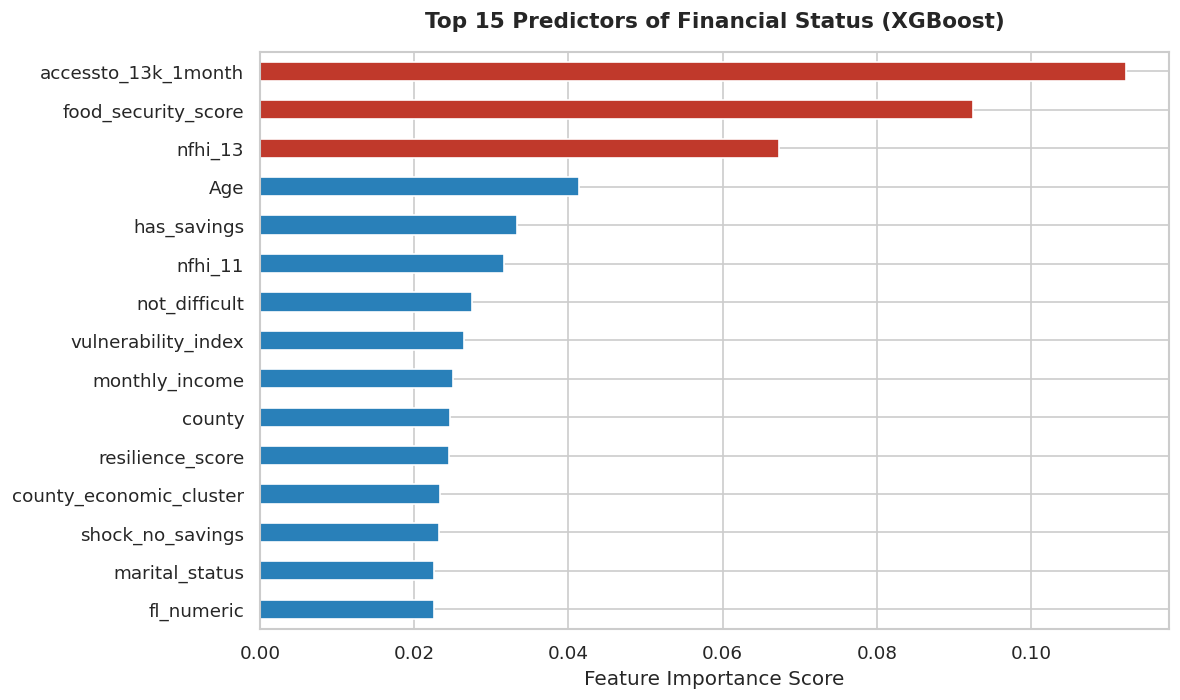

In [ ]:
# ── Feature Importance — Final Best Model ────────────────────────────────────
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['#c0392b' if i < 3 else '#2980b9' for i in range(len(feat_imp))]
feat_imp[::-1].plot(kind='barh', ax=ax, color=colors_fi[::-1], edgecolor='white')
ax.set_title('Top 15 Predictors of Financial Status (XGBoost)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('chart12_feature_importance.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── Final Summary Print ───────────────────────────────────────────────────────
print('=' * 65)
print('      THE PGs — DataSprint 2026 | FINAL RESULTS')
print('=' * 65)
print()
print('📌 DATASET')
print(f'   {len(df):,} Kenyan adults | 47 counties | 28 raw + 11 engineered features')
print()
print('📌 KEY FINDING')
worsened_pct = (df['financial_status'] == 'Worsened').mean() * 100
shock_no_sav = df[df['shock_no_savings'] == 1]['financial_status']
shock_no_sav_pct = (shock_no_sav == 'Worsened').mean() * 100
print(f'   • {worsened_pct:.1f}% of Kenyans experienced worsened financial status')
print(f'   • Those with shock + no savings: {shock_no_sav_pct:.1f}% worsened — highest risk group')
print(f'   • Kisumu, Tana River, Homa Bay = highest county risk')
print()
print('📌 MODEL PERFORMANCE (Weighted F1-Score)')
for name, score in zip(
    ['Logistic Regression', 'Decision Tree    ', 'Random Forest    ',
     'XGBoost          ', 'LightGBM         ', 'Voting Ensemble  '],
    [f1_lr, f1_dt, f1_rf, f1_xgb, f1_lgbm, f1_vote]):
    marker = '  ← 🏆 WINNER' if name.strip() == 'Voting Ensemble' else ''
    print(f'   {name} : {score:.4f}{marker}')
print()
print('📌 POLICY RECOMMENDATIONS')
print('   1. Prioritise savings access for shock-exposed households')
print('   2. Targeted financial literacy in Tier-1 counties (Turkana, Tana River)')
print('   3. Expand mobile money to reduce digital exclusion in rural areas')
print('   4. Emergency fund programmes for households with vulnerability index > 5')
print('=' * 65)


      THE PGs — DataSprint 2026 | FINAL RESULTS

📌 DATASET
   20,871 Kenyan adults | 47 counties | 28 raw + 11 engineered features

📌 KEY FINDING
   • 52.6% of Kenyans experienced worsened financial status
   • Those with shock + no savings: 61.6% worsened — highest risk group
   • Kisumu, Tana River, Homa Bay = highest county risk

📌 MODEL PERFORMANCE (Weighted F1-Score)
   Logistic Regression : 0.5027
   Decision Tree     : 0.4977
   Random Forest     : 0.5340
   XGBoost           : 0.5380
   LightGBM          : 0.5357
   Voting Ensemble   : 0.5517  ← 🏆 WINNER

📌 POLICY RECOMMENDATIONS
   1. Prioritise savings access for shock-exposed households
   2. Targeted financial literacy in Tier-1 counties (Turkana, Tana River)
   3. Expand mobile money to reduce digital exclusion in rural areas
   4. Emergency fund programmes for households with vulnerability index > 5


In [ ]:
import joblib
# ── Model Export for Deployment ──────────────────────────────────────────────
# Saving the ensemble and the pre-processing tools
model_artifacts = {
    'model': voting,
    'scaler': scaler,
    'le_dict': le_dict,
    'le_target': le_target,
    'features': X_train.columns.tolist()
}
joblib.dump(model_artifacts, 'finaccess_winning_model.pkl')
print('✅ Model artifacts exported to finaccess_winning_model.pkl')
print('🚀 This model is now ready for a production API or Dashboard.')

✅ Model artifacts exported to finaccess_winning_model.pkl
🚀 This model is now ready for a production API or Dashboard.
